# 07 · EBSD Regular-Grid Workflows

**Where this sits in PyTex.** Electron backscatter diffraction (EBSD) produces an
orientation *per pixel* on a regular grid. Turning that raw map into microstructural
insight — local misorientation, grains, deformation gradients — is the EBSD domain of
PyTex. This notebook builds a synthetic but physically meaningful `CrystalMap` and runs
the core regular-grid analyses: neighbour graphs, **KAM**, **grain segmentation**,
**GOS/GROD**, and grain boundaries.

## Learning goals

1. assemble a `CrystalMap` on a regular grid with a phase and per-pixel orientations;
2. compute **kernel-average misorientation** (KAM) and see it light up boundaries;
3. **segment grains** at a misorientation threshold and count them;
4. read grain-level statistics — sizes, **grain orientation spread** (GOS), **GROD**;
5. render **IPF** and **KAM** maps with a grain-boundary overlay.

## Theory

EBSD analysis is built on *local misorientation*. For each pixel, the disorientation
(Notebook 02) to its neighbours measures lattice curvature. The **kernel-average
misorientation**

$$
\mathrm{KAM}_i = \frac{1}{|N_i|}\sum_{j\in N_i}\omega(g_i, g_j)
$$

is small inside a grain (smooth lattice) and large across a boundary — so KAM is both a
strain-proxy and an edge detector. **Grain segmentation** grows regions whose
neighbour disorientation stays below a threshold (commonly $5^\circ$ for
high-angle boundaries). Within a grain, **GROD** (grain reference orientation
deviation) measures each pixel's deviation from the grain's mean orientation, and
**GOS** (grain orientation spread) is its average — classic indicators of stored plastic
strain. (Wright, Nowell & Field, *Microsc. Microanal.* 2011; Kocks, Tomé & Wenk 1998.)

In [1]:
from __future__ import annotations

import warnings

import numpy as np

warnings.filterwarnings("ignore", message="Issues encountered while parsing CIF")
warnings.filterwarnings("ignore", message="No _symmetry_equiv_pos_as_xyz")

from pytex import (
    CrystalMap,
    CrystalMapPhase,
    FrameDomain,
    OrientationSet,
    ReferenceFrame,
    get_phase_fixture,
    plot_ipf_map,
    plot_kam_map,
)

np.set_printoptions(precision=3, suppress=True)

crystal = ReferenceFrame("crystal", FrameDomain.CRYSTAL, ("a", "b", "c"))
specimen = ReferenceFrame("specimen", FrameDomain.SPECIMEN, ("x", "y", "z"))
map_frame = ReferenceFrame("map", FrameDomain.MAP, ("i", "j", "k"))
phase = get_phase_fixture("ni_fcc").load_phase(crystal_frame=crystal)
symmetry = phase.symmetry

## 1 · A synthetic two-grain map with intragranular gradient

We lay down a $24\times24$ grid split into a left and a right grain. The two grains
differ by a large ($\sim30^\circ$) misorientation — a high-angle boundary — and each
carries a gentle orientation gradient along $y$ to mimic stored strain. A `CrystalMap`
binds these orientations to their grid coordinates, the map frame, and the phase.

In [2]:
ny, nx = 24, 24
row, col = np.meshgrid(np.arange(ny), np.arange(nx), indexing="ij")
coordinates = np.column_stack([col.ravel().astype(float), row.ravel().astype(float)])

# left grain near (10,0,0), right grain near (40,10,0); +0.15 deg/step gradient in y.
phi1 = np.where(col.ravel() < nx / 2, 10.0, 40.0) + 0.15 * row.ravel()
Phi = np.where(col.ravel() < nx / 2, 0.0, 10.0)
euler = np.column_stack([phi1, Phi, np.zeros_like(phi1)])

orientations = OrientationSet.from_euler_angles(
    euler, crystal_frame=crystal, specimen_frame=specimen,
    symmetry=symmetry, degrees=True, phase=phase,
)
crystal_map = CrystalMap(
    coordinates=coordinates, orientations=orientations, map_frame=map_frame,
    phase_entries=(CrystalMapPhase(phase_id=1, name=phase.name, symmetry=symmetry, phase=phase),),
    phase_ids=np.ones(coordinates.shape[0], dtype=int),
    grid_shape=(ny, nx), step_sizes=(1.0, 1.0),
)
summary = crystal_map.summary()
print("point count :", summary["point_count"])
print("grid shape  :", summary["grid_shape"])
print("step sizes  :", summary["step_sizes"])

point count : 576
grid shape  : (24, 24)
step sizes  : (1.0, 1.0)


## 2 · Kernel-average misorientation as an edge detector

`kernel_average_misorientation_deg` returns a per-pixel value. We compare the median
KAM *inside* the left grain (smooth gradient → low KAM) with the KAM *at the central
column* straddling the boundary (large jump → high KAM). The boundary KAM is more than
an order of magnitude higher — KAM has found the grain boundary without being told
where it is.

In [3]:
kam = crystal_map.kernel_average_misorientation_deg().reshape(ny, nx)

interior = kam[:, 2:8]           # well inside the left grain
boundary = kam[:, nx // 2 - 1:nx // 2 + 1]  # columns straddling the boundary
print(f"median KAM inside left grain : {np.median(interior):.3f} deg")
print(f"median KAM at the boundary   : {np.median(boundary):.3f} deg")
assert np.median(boundary) > 10 * np.median(interior)

median KAM inside left grain : 0.075 deg
median KAM at the boundary   : 7.972 deg


## 3 · Grain segmentation

`segment_grains` grows grains wherever neighbour disorientation stays below the
threshold. At $5^\circ$ the intragranular gradient ($\sim0.15^\circ$ per step) never
breaks a grain, but the $\sim30^\circ$ boundary does — so the map segments into exactly
**two** grains, whose sizes sum to the pixel count.

In [4]:
segmentation = crystal_map.segment_grains(max_misorientation_deg=5.0)
grain_count = len(segmentation.grains)
sizes = segmentation.grain_sizes()   # {grain_label: pixel_count}
print("number of grains :", grain_count)
print("grain sizes (px) :", sizes)
assert grain_count == 2
assert sum(sizes.values()) == ny * nx

number of grains : 2
grain sizes (px) : {0: 288, 1: 288}


## 4 · Grain reference orientation deviation and spread

Within each grain, GROD measures the per-pixel deviation from the grain's mean
orientation; GOS is the grain-average of GROD. Because our grains carry a real
gradient, both are non-zero and bounded by the total imposed gradient (a few degrees) —
a quantitative stand-in for stored plastic strain.

In [5]:
grod = np.asarray(segmentation.grod_map_deg())
gos = segmentation.grain_orientation_spread_deg()   # {grain_label: spread_deg}
print(f"GROD range across map : {np.nanmin(grod):.3f} .. {np.nanmax(grod):.3f} deg")
print("grain orientation spread (GOS) per grain :",
      {label: round(value, 3) for label, value in gos.items()})
assert np.nanmax(grod) < 10.0  # bounded by the imposed intragranular gradient

GROD range across map : 0.000 .. 1.800 deg
grain orientation spread (GOS) per grain : {0: 0.9, 1: 0.9}


## 5 · Mapping it: IPF and KAM with a boundary overlay

Finally the standard EBSD figures. The IPF map colours each pixel by which crystal axis
points along the sample $z$; the two grains read as two colours. The KAM map, with the
segmented grain boundary overlaid, shows the low-strain grain interiors against the
bright boundary.

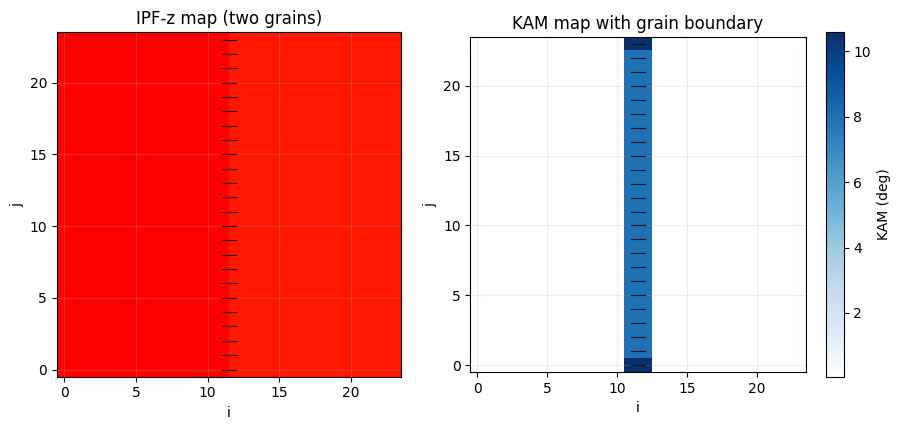

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.4))
plot_ipf_map(crystal_map, direction="z", boundary_overlay=segmentation, ax=axes[0])
axes[0].set_title("IPF-z map (two grains)")
plot_kam_map(crystal_map, boundary_overlay=segmentation, ax=axes[1])
axes[1].set_title("KAM map with grain boundary")
fig.tight_layout()


## Summary and where to go next

- A **`CrystalMap`** binds per-pixel orientations to a regular grid, phase, and frames.
- **KAM** measures local lattice curvature and doubles as a boundary detector.
- **`segment_grains`** partitions the map at a disorientation threshold; grain-level
  **GROD/GOS** quantify intragranular strain.
- **IPF** and **KAM** maps with boundary overlays are produced directly from the map.

**Next:** [Notebook 16](16_ebsd_to_texture_outputs.ipynb) carries a `CrystalMap` all the
way to ODF and pole-figure outputs; the acquisition/manifest layer of
[Notebook 05](05_multimodal_acquisition_and_manifests.ipynb) records how such a map was
collected.